## Algebra lineare numerica: basics


### Spazi vettoriali

Un **gruppo** è un insieme dotato di un'operazione che soddisfa quattro proprietà:

1. chiusura;
2. associatività;
3. esistenza di un elemento neutro;
4. esistenza dell'inverso per ogni elemento.

Uno **spazio vettoriale reale** $V$ aggiunge a questa struttura la moltiplicazione dei vettori per scalari $\lambda\in\mathbb{R}$. Le due operazioni fondamentali sono quindi

$$
\boldsymbol{x}+\boldsymbol{y}\in V,
\qquad
\lambda\boldsymbol{x}\in V.
$$

Esse devono rispettare le usuali proprietà di associatività, distributività ed elemento neutro.

Esempi importanti sono $\mathbb{R}^n$, l'insieme delle matrici $\mathbb{R}^{m\times n}$ e l'insieme dei numeri complessi visto come spazio vettoriale reale.



Un sottoinsieme non vuoto $U\subseteq V$ è un **sottospazio vettoriale** se è chiuso rispetto alle operazioni dello spazio:

$$
\boldsymbol{x},\boldsymbol{y}\in U
\Longrightarrow
\boldsymbol{x}+\boldsymbol{y}\in U,
$$

$$
\boldsymbol{x}\in U,\ \lambda\in\mathbb{R}
\Longrightarrow
\lambda\boldsymbol{x}\in U.
$$

In particolare, ogni sottospazio deve contenere il vettore nullo.

Un esempio fondamentale è l'insieme delle soluzioni del sistema omogeneo

$$
A\boldsymbol{x}=\boldsymbol{0},
$$

che costituisce sempre un sottospazio. Al contrario, l'insieme delle soluzioni di $A\boldsymbol{x}=\boldsymbol{b}$ con $\boldsymbol{b}\neq\boldsymbol{0}$, se non vuoto, in generale non è un sottospazio vettoriale.

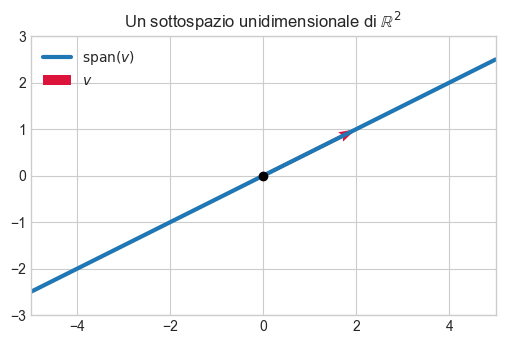

In [136]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# Il sottospazio generato dal vettore v è una retta passante per l'origine.
v = np.array([2.0, 1.0])
t = np.linspace(-2.5, 2.5, 100)
punti = np.outer(t, v)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(punti[:, 0], punti[:, 1], lw=3, label=r"$\mathrm{span}(v)$")
ax.quiver(0, 0, *v, angles="xy", scale_units="xy", scale=1,
          color="crimson", label=r"$v$")
ax.scatter(0, 0, color="black", zorder=3)
ax.set_xlim(-5, 5)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.set_title(r"Un sottospazio unidimensionale di $\mathbb{R}^2$")
ax.legend()
plt.show()

### Combinazioni e indipendenza lineare

Una **combinazione lineare** dei vettori $\boldsymbol{x}_1,\ldots,\boldsymbol{x}_k$ è un vettore della forma

$$
\boldsymbol{v}
=\lambda_1\boldsymbol{x}_1+\cdots+\lambda_k\boldsymbol{x}_k.
$$

I vettori sono **linearmente indipendenti** se l'uguaglianza

$$
\lambda_1\boldsymbol{x}_1+\cdots+\lambda_k\boldsymbol{x}_k=\boldsymbol{0}
$$

implica necessariamente $\lambda_1=\cdots=\lambda_k=0$. In caso contrario sono linearmente dipendenti.

L'interpretazione essenziale è la seguente:

> un insieme di vettori indipendenti non contiene informazione ridondante.

Per controllare l'indipendenza si possono disporre i vettori come colonne di una matrice $A$ e studiare il sistema omogeneo $A\boldsymbol{\lambda}=\boldsymbol{0}$.

In [137]:
# v3 è una combinazione lineare di v1 e v2: v3 = v1 + 2 v2.
v1 = np.array([1, 0, 1])
v2 = np.array([0, 1, 1])
v3 = v1 + 2 * v2

A = np.column_stack([v1, v2, v3])

print("Matrice con i vettori come colonne:\n", A)
print("Rango:", np.linalg.matrix_rank(A))
print("Numero di colonne:", A.shape[1])
print("I tre vettori sono dipendenti perché il rango è minore del numero di colonne.")

Matrice con i vettori come colonne:
 [[1 0 1]
 [0 1 2]
 [1 1 3]]
Rango: 2
Numero di colonne: 3
I tre vettori sono dipendenti perché il rango è minore del numero di colonne.


### Insieme generatore, base, dimensione e rango

Lo **span** di un insieme di vettori è l'insieme di tutte le loro combinazioni lineari:

$$
\operatorname{span}(\boldsymbol{x}_1,\ldots,\boldsymbol{x}_k)
=
\left\{
\sum_{i=1}^k\lambda_i\boldsymbol{x}_i:\lambda_i\in\mathbb{R}
\right\}.
$$

Se lo span coincide con $V$, i vettori formano un **insieme generatore** di $V$.

Una **base** di $V$ è un insieme di vettori che:

- genera tutto $V$;
- è linearmente indipendente.

Di conseguenza, ogni vettore di $V$ possiede una rappresentazione **unica** come combinazione lineare dei vettori di base. Una base definisce quindi un sistema di coordinate.

Tutte le basi di uno spazio vettoriale finito hanno lo stesso numero di elementi: tale numero è la **dimensione** dello spazio.

In [138]:
# Lo stesso vettore espresso in due basi diverse.
x = np.array([2.0, 3.0])

# Le colonne di B sono i vettori della nuova base.
B = np.array([[1.0, 1.0],
              [-1.0, 1.0]])

coordinate_in_B = np.linalg.solve(B, x)

print("Coordinate nella base canonica:", x)
print("Coordinate nella base B:", coordinate_in_B)
print("Ricostruzione B @ coordinate:", B @ coordinate_in_B)

Coordinate nella base canonica: [2. 3.]
Coordinate nella base B: [-0.5  2.5]
Ricostruzione B @ coordinate: [2. 3.]




Il **rango** di una matrice $A$ è il numero delle sue colonne linearmente indipendenti; coincide anche con il numero delle righe linearmente indipendenti:

$$
\operatorname{rk}(A)
=\dim(\text{spazio delle colonne di }A).
$$

Proprietà principali:

- $\operatorname{rk}(A)=\operatorname{rk}(A^T)$;
- se $A\in\mathbb{R}^{n\times n}$, allora $A$ è invertibile se e solo se $\operatorname{rk}(A)=n$;
- $A\boldsymbol{x}=\boldsymbol{b}$ è risolvibile se il rango di $A$ coincide con quello della matrice aumentata $[A\mid\boldsymbol{b}]$;
- $A\in\mathbb{R}^{m\times n}$ ha rango pieno se $\operatorname{rk}(A)=\min(m,n)$.

Il rango misura quante direzioni indipendenti — e quindi quanta informazione non ridondante — sono presenti nella matrice.

In [139]:
A = np.array([[1, 2, 3],
              [2, 4, 6],
              [1, 1, 1]])

print("A =\n", A)
print("rango(A) =", np.linalg.matrix_rank(A))
print("La seconda riga è il doppio della prima: la matrice è a rango ridotto.")

A =
 [[1 2 3]
 [2 4 6]
 [1 1 1]]
rango(A) = 2
La seconda riga è il doppio della prima: la matrice è a rango ridotto.


## Applicazioni lineari

Una funzione $\Phi:V\rightarrow W$ è un'**applicazione lineare** se conserva combinazioni lineari:

$$
\Phi(\lambda\boldsymbol{x}+\mu\boldsymbol{y})
=
\lambda\Phi(\boldsymbol{x})+\mu\Phi(\boldsymbol{y}).
$$

Sono casi importanti:

- **iniettiva**: vettori diversi hanno immagini diverse;
- **suriettiva**: ogni elemento del codominio viene raggiunto;
- **biiettiva**: è sia iniettiva sia suriettiva e possiede un'inversa;
- **isomorfismo**: applicazione lineare biiettiva tra due spazi vettoriali.

Due spazi vettoriali finito-dimensionali sono isomorfi se e solo se hanno la stessa dimensione.

 **Rappresentazione matriciale**

Scelte una base $B=(\boldsymbol{b}_1,\ldots,\boldsymbol{b}_n)$ di $V$ e una base $C$ di $W$, ogni applicazione lineare $\Phi:V\rightarrow W$ può essere rappresentata da una matrice $A_{\Phi}$:

$$
[\Phi(\boldsymbol{x})]_C=A_{\Phi}[\boldsymbol{x}]_B.
$$

La colonna $j$ di $A_{\Phi}$ contiene le coordinate di $\Phi(\boldsymbol{b}_j)$ nella base $C$.

È importante distinguere tra:

- l'applicazione lineare, che è un oggetto astratto;
- la matrice che la rappresenta, che dipende dalle basi scelte.

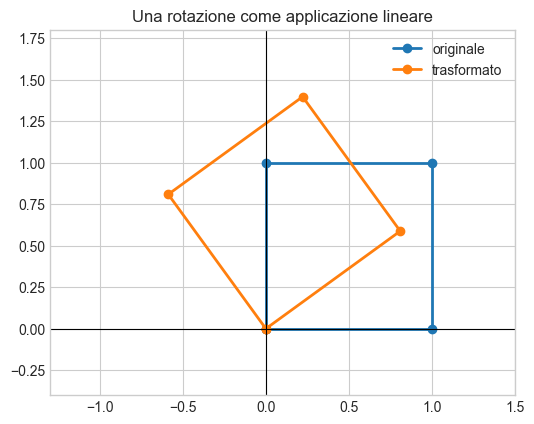

In [140]:
# Una matrice può ruotare, dilatare o deformare un insieme di punti.
theta = np.pi / 5
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

quadrato = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]], dtype=float)
trasformato = (R @ quadrato.T).T

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(quadrato[:, 0], quadrato[:, 1], "o-", lw=2, label="originale")
ax.plot(trasformato[:, 0], trasformato[:, 1], "o-", lw=2, label="trasformato")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlim(-1.3, 1.5)
ax.set_ylim(-0.4, 1.8)
ax.set_aspect("equal")
ax.set_title("Una rotazione come applicazione lineare")
ax.legend()
plt.show()


Cambiare base significa descrivere gli stessi vettori con coordinate diverse. Anche la matrice che rappresenta un'applicazione lineare cambia, pur restando invariata l'applicazione astratta.

Se cambiano sia la base del dominio sia quella del codominio, le matrici di cambiamento di base permettono di convertire una rappresentazione nell'altra. Nel caso di un endomorfismo $\Phi:V\to V$, la trasformazione assume la forma

$$
\widetilde{A}=S^{-1}AS.
$$

Le matrici $A$ e $\widetilde{A}$ sono dette **simili**. La scelta di una base conveniente può rendere la rappresentazione molto più semplice; questo principio sarà centrale nella diagonalizzazione, nella SVD e nella PCA.



Per un'applicazione lineare $\Phi:V\rightarrow W$ si definiscono:

$$
\ker(\Phi)=\{\boldsymbol{v}\in V:\Phi(\boldsymbol{v})=\boldsymbol{0}\},
$$

$$
\operatorname{Im}(\Phi)=\{\Phi(\boldsymbol{v}):\boldsymbol{v}\in V\}.
$$

- il **nucleo** contiene le direzioni annullate dalla trasformazione;
- l'**immagine** contiene tutti i vettori raggiungibili.

Se $\Phi(\boldsymbol{x})=A\boldsymbol{x}$, allora l'immagine è lo spazio generato dalle colonne di $A$, mentre il nucleo è l'insieme delle soluzioni di $A\boldsymbol{x}=\boldsymbol{0}$.

Inoltre, $\Phi$ è iniettiva se e solo se $\ker(\Phi)=\{\boldsymbol{0}\}$.



Per una trasformazione lineare $\Phi:V\rightarrow W$, con $V$ finito-dimensionale,

$$
\boxed{
\dim\bigl(\ker(\Phi)\bigr)
+
\dim\bigl(\operatorname{Im}(\Phi)\bigr)
=
\dim(V)
}
$$

Per una matrice $A\in\mathbb{R}^{m\times n}$:

$$
\operatorname{nullità}(A)+\operatorname{rk}(A)=n.
$$

Le $n$ dimensioni del dominio si dividono quindi tra direzioni conservate nell'immagine e direzioni perse nel nucleo.

In [141]:
A = np.array([[1.0, 2.0, 3.0],
              [2.0, 4.0, 6.0]])

rank = np.linalg.matrix_rank(A)
nullity = A.shape[1] - rank

print("dimensione del dominio =", A.shape[1])
print("dimensione dell'immagine (rango) =", rank)
print("dimensione del nucleo (nullità) =", nullity)
print("verifica rango + nullità =", rank + nullity)

dimensione del dominio = 3
dimensione dell'immagine (rango) = 1
dimensione del nucleo (nullità) = 2
verifica rango + nullità = 3


### Spazi affini

Un **sottospazio affine** è la traslazione di un sottospazio vettoriale:

$$
L=\boldsymbol{x}_0+U
=\{\boldsymbol{x}_0+\boldsymbol{u}:\boldsymbol{u}\in U\}.
$$

Qui $\boldsymbol{x}_0$ è un punto di supporto e $U$ è lo spazio delle direzioni. A differenza di un sottospazio vettoriale, uno spazio affine non deve passare per l'origine.

Esempi:

- un punto è uno spazio affine di dimensione zero;
- una retta affine è $\boldsymbol{x}_0+\lambda\boldsymbol{b}$;
- un piano affine è $\boldsymbol{x}_0+\lambda_1\boldsymbol{b}_1+\lambda_2\boldsymbol{b}_2$;
- un iperpiano in $\mathbb{R}^n$ ha dimensione $n-1$.

Se il sistema $A\boldsymbol{x}=\boldsymbol{b}$ è compatibile, il suo insieme di soluzioni è uno spazio affine di dimensione $n-\operatorname{rk}(A)$.

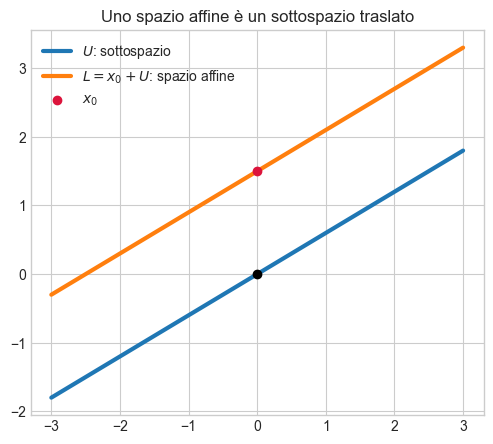

In [142]:
# Confronto tra un sottospazio e una retta affine parallela.
t = np.linspace(-3, 3, 100)
direzione = np.array([1.0, 0.6])
x0 = np.array([0.0, 1.5])

U = np.outer(t, direzione)
L = x0 + U

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(U[:, 0], U[:, 1], lw=3, label=r"$U$: sottospazio")
ax.plot(L[:, 0], L[:, 1], lw=3, label=r"$L=x_0+U$: spazio affine")
ax.scatter(*x0, color="crimson", zorder=3, label=r"$x_0$")
ax.scatter(0, 0, color="black", zorder=3)
ax.set_aspect("equal")
ax.set_title("Uno spazio affine è un sottospazio traslato")
ax.legend()
plt.show()

## Applicazioni affini

Un'**applicazione affine** ha la forma

$$
\phi(\boldsymbol{x})
=\boldsymbol{a}+\Phi(\boldsymbol{x}),
$$

dove $\Phi$ è lineare e $\boldsymbol{a}$ è un vettore di traslazione. In coordinate:

$$
\phi(\boldsymbol{x})=A\boldsymbol{x}+\boldsymbol{a}.
$$

Se $\boldsymbol{a}\neq\boldsymbol{0}$, l'applicazione non è lineare perché in generale $\phi(\boldsymbol{0})\neq\boldsymbol{0}$.

Nella letteratura sul machine learning, modelli della forma $A\boldsymbol{x}+\boldsymbol{b}$ vengono spesso chiamati “lineari”, anche se matematicamente sono affini. Il termine $\boldsymbol{b}$ è il **bias** o intercetta.

In [143]:
A = np.array([[2.0, 0.0],
              [0.0, 0.5]])
b = np.array([1.0, -1.0])

def trasformazione_affine(x):
    return A @ x + b

x = np.array([2.0, 4.0])
print("phi(x) =", trasformazione_affine(x))
print("phi(0) =", trasformazione_affine(np.zeros(2)))
print("Poiché phi(0) non è 0, la trasformazione è affine ma non lineare.")

phi(x) = [5. 1.]
phi(0) = [ 1. -1.]
Poiché phi(0) non è 0, la trasformazione è affine ma non lineare.


## Schema riassuntivo

| Concetto | Idea essenziale |
|---|---|
| Spazio vettoriale | Ambiente chiuso rispetto a somma e moltiplicazione per scalari |
| Sottospazio | Parte dello spazio che conserva la stessa struttura |
| Combinazione lineare | Somma pesata di vettori |
| Indipendenza lineare | Assenza di ridondanza tra vettori |
| Span | Insieme di tutte le combinazioni lineari |
| Base | Insieme indipendente che genera tutto lo spazio |
| Dimensione | Numero di vettori di una base |
| Rango | Numero di direzioni indipendenti di una matrice |
| Applicazione lineare | Trasformazione che conserva le combinazioni lineari |
| Cambiamento di base | Nuove coordinate per gli stessi oggetti |
| Nucleo | Direzioni annullate dalla trasformazione |
| Immagine | Insieme dei risultati raggiungibili |
| Spazio affine | Sottospazio vettoriale traslato |
| Applicazione affine | Trasformazione $A\boldsymbol{x}+\boldsymbol{b}$ |

## Domande rapide di autoverifica

1. Perché una retta che non passa per l'origine non è un sottospazio vettoriale?
2. Qual è la differenza tra un insieme generatore e una base?
3. Che cosa misura il rango di una matrice?
4. Perché la matrice di un'applicazione lineare dipende dalla base scelta?
5. Che cosa rappresentano geometricamente nucleo e immagine?
6. Perché $A\boldsymbol{x}+\boldsymbol{b}$ con $\boldsymbol{b}\neq0$ è affine ma non lineare?

### Norme

Una **norma** assegna a ogni vettore $\boldsymbol{x}\in V$ una lunghezza $\|\boldsymbol{x}\|$. Deve soddisfare:

1. **positività**: $\|\boldsymbol{x}\|\geq 0$ e $\|\boldsymbol{x}\|=0$ solo per $\boldsymbol{x}=\boldsymbol{0}$;
2. **omogeneità**: $\|\lambda\boldsymbol{x}\|=|\lambda|\,\|\boldsymbol{x}\|$;
3. **disuguaglianza triangolare**: $\|\boldsymbol{x}+\boldsymbol{y}\|\leq\|\boldsymbol{x}\|+\|\boldsymbol{y}\|$.

Le norme più comuni in $\mathbb{R}^n$ sono

$$
\|\boldsymbol{x}\|_1=\sum_{i=1}^n |x_i|,
\qquad
\|\boldsymbol{x}\|_2=\sqrt{\sum_{i=1}^n x_i^2},
\qquad
\|\boldsymbol{x}\|_\infty=\max_i |x_i|.
$$

La norma euclidea $\|\cdot\|_2$ è quella usata per default nel libro.

In [144]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

x = np.array([3.0, -4.0])
print("x =", x)
print("norma 1        =", np.linalg.norm(x, 1))
print("norma 2        =", np.linalg.norm(x, 2))
print("norma infinito =", np.linalg.norm(x, np.inf))

x = [ 3. -4.]
norma 1        = 7.0
norma 2        = 5.0
norma infinito = 4.0


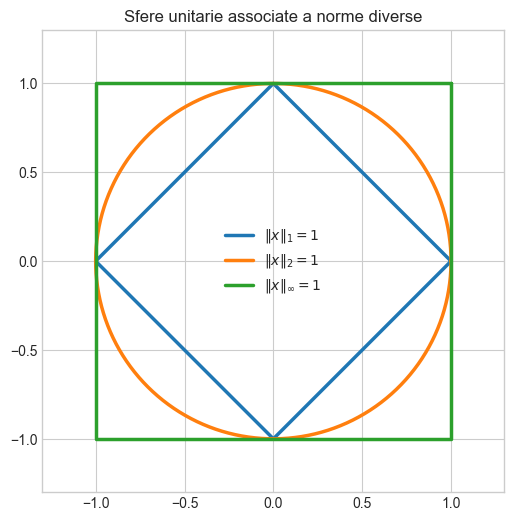

In [145]:
# In R^2, l'insieme dei vettori di norma 1 cambia forma con la norma.
t = np.linspace(0, 2 * np.pi, 500)

cerchio = np.column_stack([np.cos(t), np.sin(t)])
quadrato_l1 = np.array([[1, 0], [0, 1], [-1, 0], [0, -1], [1, 0]])
quadrato_linf = np.array([[1, 1], [-1, 1], [-1, -1], [1, -1], [1, 1]])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(quadrato_l1[:, 0], quadrato_l1[:, 1], lw=2.5, label=r"$\|x\|_1=1$")
ax.plot(cerchio[:, 0], cerchio[:, 1], lw=2.5, label=r"$\|x\|_2=1$")
ax.plot(quadrato_linf[:, 0], quadrato_linf[:, 1], lw=2.5,
        label=r"$\|x\|_\infty=1$")
ax.set_aspect("equal")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_title("Sfere unitarie associate a norme diverse")
ax.legend()
plt.show()

### Prodotti scalari

Un **prodotto scalare** è una funzione $\langle\cdot,\cdot\rangle:V\times V\to\mathbb{R}$ bilineare, simmetrica e definita positiva.

In $\mathbb{R}^n$, il prodotto scalare standard è

$$
\langle\boldsymbol{x},\boldsymbol{y}\rangle
=\boldsymbol{x}^T\boldsymbol{y}
=\sum_{i=1}^n x_i y_i.
$$

Più in generale, una matrice simmetrica definita positiva $A$ definisce

$$
\langle\boldsymbol{x},\boldsymbol{y}\rangle_A
=\boldsymbol{x}^T A\boldsymbol{y}.
$$

Il prodotto scalare stabilisce la geometria dello spazio: cambiandolo possono cambiare lunghezze, angoli e ortogonalità.

In [146]:
x = np.array([1.0, 1.0])
y = np.array([-1.0, 1.0])
A = np.array([[2.0, 0.5],
              [0.5, 1.0]])

print("Prodotto scalare standard:", x @ y)
print("Prodotto scalare definito da A:", x @ A @ y)

Prodotto scalare standard: 0.0
Prodotto scalare definito da A: -1.0




Ogni prodotto scalare induce una norma:

$$
\|\boldsymbol{x}\|=\sqrt{\langle\boldsymbol{x},\boldsymbol{x}\rangle}.
$$

Una norma induce a sua volta la distanza

$$
d(\boldsymbol{x},\boldsymbol{y})
=\|\boldsymbol{x}-\boldsymbol{y}\|.
$$

Una distanza, o **metrica**, è non negativa, simmetrica, nulla solo tra punti identici e soddisfa la disuguaglianza triangolare.

Nell'analisi dei dati, punti vicini rappresentano osservazioni simili. La scelta della metrica determina quindi che cosa intendiamo per “simile”.

In [147]:
x = np.array([1.0, 2.0, 3.0])
y = np.array([2.0, 2.0, 5.0])

print("Distanza euclidea:", np.linalg.norm(x - y))
print("Distanza Manhattan:", np.linalg.norm(x - y, 1))

Distanza euclidea: 2.23606797749979
Distanza Manhattan: 3.0


### Angoli e ortogonalità

La disuguaglianza di Cauchy–Schwarz garantisce che

$$
|\langle\boldsymbol{x},\boldsymbol{y}\rangle|
\leq
\|\boldsymbol{x}\|\,\|\boldsymbol{y}\|.
$$

Per vettori non nulli possiamo quindi definire l'angolo $\omega\in[0,\pi]$ mediante

$$
\cos\omega
=\frac{\langle\boldsymbol{x},\boldsymbol{y}\rangle}
{\|\boldsymbol{x}\|\,\|\boldsymbol{y}\|}.
$$

Due vettori sono **ortogonali** se

$$
\langle\boldsymbol{x},\boldsymbol{y}\rangle=0.
$$

Se sono anche di norma unitaria, sono detti **ortonormali**.

In [148]:
x = np.array([1.0, 1.0])
y = np.array([1.0, 2.0])

coseno = (x @ y) / (np.linalg.norm(x) * np.linalg.norm(y))
angolo = np.arccos(np.clip(coseno, -1.0, 1.0))

print("coseno dell'angolo =", coseno)
print("angolo in gradi     =", np.degrees(angolo))

coseno dell'angolo = 0.9486832980505138
angolo in gradi     = 18.434948822922017




Una base $(\boldsymbol{b}_1,\ldots,\boldsymbol{b}_n)$ è ortonormale se

$$
\langle\boldsymbol{b}_i,\boldsymbol{b}_j\rangle
=
\begin{cases}
1,& i=j,\\
0,& i\neq j.
\end{cases}
$$

Le basi ortonormali semplificano molti calcoli. Se $B=[\boldsymbol{b}_1,\ldots,\boldsymbol{b}_n]$, allora $B^TB=I$ e le coordinate di un vettore sono semplicemente $B^T\boldsymbol{x}$.

Il procedimento di **Gram–Schmidt** trasforma una base qualunque in una base ortonormale dello stesso spazio.

### Matrici ortogonali

Una matrice quadrata $Q$ è **ortogonale** se le sue colonne formano una base ortonormale:

$$
Q^TQ=QQ^T=I,
\qquad
Q^{-1}=Q^T.
$$

Le trasformazioni descritte da matrici ortogonali conservano prodotti scalari, lunghezze, distanze e angoli. Rotazioni e riflessioni appartengono a questa classe.

In [149]:
# Un passo di Gram–Schmidt in R^2.
b1 = np.array([2.0, 1.0])
b2 = np.array([1.0, 2.0])

u1 = b1
u2 = b2 - (b2 @ u1) / (u1 @ u1) * u1

q1 = u1 / np.linalg.norm(u1)
q2 = u2 / np.linalg.norm(u2)
Q = np.column_stack([q1, q2])

print("Base ortonormale Q =\n", Q)
print("Verifica Q.T @ Q =\n", np.round(Q.T @ Q, 12))

Base ortonormale Q =
 [[ 0.89442719 -0.4472136 ]
 [ 0.4472136   0.89442719]]
Verifica Q.T @ Q =
 [[ 1. -0.]
 [-0.  1.]]


**Complemento ortogonale**

Sia $U$ un sottospazio di uno spazio $V$. Il suo **complemento ortogonale** è

$$
U^\perp
=\{\boldsymbol{v}\in V:
\langle\boldsymbol{v},\boldsymbol{u}\rangle=0
\text{ per ogni }\boldsymbol{u}\in U\}.
$$

Se $\dim(V)=D$ e $\dim(U)=M$, allora

$$
\dim(U^\perp)=D-M,
\qquad
U\cap U^\perp=\{\boldsymbol{0}\}.
$$

Ogni vettore di $V$ si può decomporre in modo unico come somma di una componente in $U$ e una in $U^\perp$. In $\mathbb{R}^3$, il complemento ortogonale di un piano passante per l'origine è la retta generata dal suo vettore normale.

In [150]:
t = np.linspace(-np.pi, np.pi, 10001)
u = np.sin(t)
v = np.cos(t)
prodotto = np.trapezoid(u * v, t)

print("Integrale di sin(t) cos(t) su [-pi, pi] =", prodotto)

Integrale di sin(t) cos(t) su [-pi, pi] = -5.551115123125783e-17


### Proiezioni ortogonali

Una proiezione $\pi:V\to U$, con $U\subseteq V$, soddisfa

$$
\pi^2=\pi.
$$

La proiezione ortogonale di $\boldsymbol{x}$ su $U$ è il vettore di $U$ più vicino a $\boldsymbol{x}$. L'errore

$$
\boldsymbol{x}-\pi_U(\boldsymbol{x})
$$

è ortogonale a tutto il sottospazio $U$.

### Proiezione su una retta

Se $U=\operatorname{span}(\boldsymbol{b})$, allora

$$
\pi_U(\boldsymbol{x})
=\frac{\boldsymbol{b}^T\boldsymbol{x}}
{\boldsymbol{b}^T\boldsymbol{b}}\boldsymbol{b},
$$

e la matrice di proiezione è

$$
P=\frac{\boldsymbol{b}\boldsymbol{b}^T}
{\boldsymbol{b}^T\boldsymbol{b}}.
$$

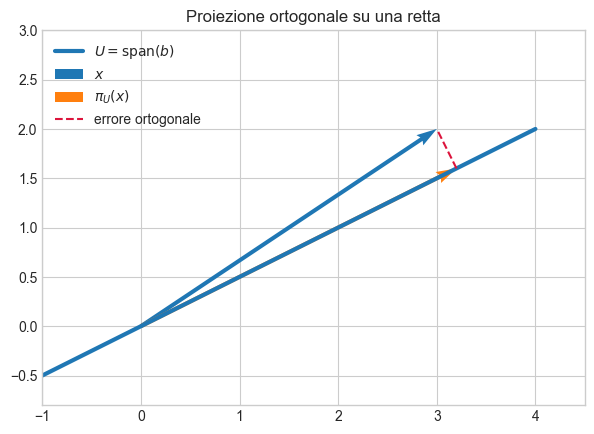

proiezione = [3.2 1.6]
b · errore = -2.220446049250313e-16
P @ P = P? True


In [151]:
x = np.array([3.0, 2.0])
b = np.array([1.0, 0.5])

P = np.outer(b, b) / (b @ b)
px = P @ x
errore = x - px

t = np.linspace(-1, 4, 100)
retta = np.outer(t, b)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(retta[:, 0], retta[:, 1], lw=3, label=r"$U=\mathrm{span}(b)$")
ax.quiver(0, 0, *x, angles="xy", scale_units="xy", scale=1,
          color="tab:blue", label=r"$x$")
ax.quiver(0, 0, *px, angles="xy", scale_units="xy", scale=1,
          color="tab:orange", label=r"$\pi_U(x)$")
ax.plot([px[0], x[0]], [px[1], x[1]], "--", color="crimson",
        label="errore ortogonale")
ax.set_xlim(-1, 4.5)
ax.set_ylim(-0.8, 3)
ax.set_aspect("equal")
ax.set_title("Proiezione ortogonale su una retta")
ax.legend()
plt.show()

print("proiezione =", px)
print("b · errore =", b @ errore)
print("P @ P = P?", np.allclose(P @ P, P))

### Proiezione su un sottospazio

Se le colonne della matrice $B\in\mathbb{R}^{n\times m}$ formano una base di $U$, allora

$$
\pi_U(\boldsymbol{x})
=B(B^TB)^{-1}B^T\boldsymbol{x},
$$

$$
P=B(B^TB)^{-1}B^T.
$$

Se le colonne di $B$ sono ortonormali, la formula si semplifica:

$$
P=BB^T.
$$

Le proiezioni collegano direttamente la geometria ai **minimi quadrati**: quando $A\boldsymbol{x}=\boldsymbol{b}$ non è risolvibile esattamente, si proietta $\boldsymbol{b}$ sullo spazio generato dalle colonne di $A$.

### Proiezione su uno spazio affine

Se $L=\boldsymbol{x}_0+U$ è uno spazio affine, si trasla prima il problema verso l'origine, si proietta su $U$ e infine si torna indietro:

$$
\pi_L(\boldsymbol{x})
=\boldsymbol{x}_0
+\pi_U(\boldsymbol{x}-\boldsymbol{x}_0).
$$

### Collegamenti con il machine learning

I concetti del capitolo ricompaiono in molti metodi:

- **distanze e angoli** misurano la similarità tra osservazioni;
- **ortogonalità** e basi ortonormali semplificano rappresentazioni e calcoli;
- **proiezioni** descrivono minimi quadrati, regressione e PCA;
- **complementi ortogonali** distinguono informazione conservata e informazione scartata;
- **rotazioni** e trasformazioni ortogonali cambiano coordinate senza deformare la geometria.

## Schema riassuntivo

| Concetto | Significato essenziale |
|---|---|
| Norma | Lunghezza di un vettore |
| Prodotto scalare | Strumento che definisce la geometria |
| Metrica | Distanza tra due elementi |
| Angolo | Similarità tra le direzioni di due vettori |
| Ortogonalità | Prodotto scalare nullo |
| Base ortonormale | Base con vettori unitari e mutuamente ortogonali |
| Complemento ortogonale | Direzioni ortogonali a un sottospazio |
| Proiezione | Punto del sottospazio più vicino al vettore dato |

## Domande rapide di autoverifica

1. Quali proprietà deve soddisfare una norma?
2. In che modo un prodotto scalare definisce una norma?
3. Quando due vettori sono ortogonali?
4. Perché una matrice ortogonale conserva le lunghezze?
5. Che cosa rappresenta il complemento ortogonale di un sottospazio?
6. Perché l'errore di proiezione è ortogonale al sottospazio?
7. Qual è il legame tra proiezioni e minimi quadrati?

## Alcuni esempi

In [152]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

## Esempio 1 — Norma Manhattan e norma euclidea

Le prime due tipologie di norma presentate nel capitolo sono

$$
\|\boldsymbol{x}\|_1=\sum_{i=1}^n |x_i|,
\qquad
\|\boldsymbol{x}\|_2=\sqrt{\sum_{i=1}^n x_i^2}.
$$

Consideriamo

$$
\boldsymbol{x}=\begin{bmatrix}3\\-4\end{bmatrix}.
$$

Si ottiene

$$
\|\boldsymbol{x}\|_1=|3|+|-4|=7,
$$

$$
\|\boldsymbol{x}\|_2=\sqrt{3^2+(-4)^2}=5.
$$

La norma $1$ misura la lunghezza di un percorso che si muove parallelamente agli assi; la norma $2$ misura la distanza in linea retta dall'origine.

Norma 1: 7.0
Norma 2: 5.0


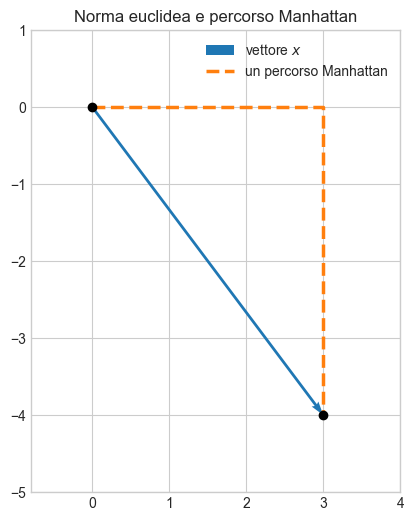

In [153]:
x = np.array([3.0, -4.0])

norma_1 = np.sum(np.abs(x))
norma_2 = np.sqrt(x @ x)

print("Norma 1:", norma_1)
print("Norma 2:", norma_2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(0, 0, *x, angles="xy", scale_units="xy", scale=1,
          color="tab:blue", label=r"vettore $x$")
ax.plot([0, 3, 3], [0, 0, -4], "--", lw=2.5, color="tab:orange",
        label="un percorso Manhattan")
ax.scatter([0, 3], [0, -4], color="black", zorder=3)
ax.set_xlim(-0.8, 4)
ax.set_ylim(-5, 1)
ax.set_aspect("equal")
ax.set_title("Norma euclidea e percorso Manhattan")
ax.legend()
plt.show()

## Esempio 2 — Matrici simmetriche definite positive

Il capitolo considera le matrici

$$
A_1=
\begin{bmatrix}
9&6\\
6&5
\end{bmatrix},
\qquad
A_2=
\begin{bmatrix}
9&6\\
6&3
\end{bmatrix}.
$$

Per ogni $\boldsymbol{x}=(x_1,x_2)^T$,

$$
\boldsymbol{x}^TA_1\boldsymbol{x}
=9x_1^2+12x_1x_2+5x_2^2
=(3x_1+2x_2)^2+x_2^2>0
$$

quando $\boldsymbol{x}\neq\boldsymbol{0}$. Quindi $A_1$ è definita positiva.

Per $A_2$, invece,

$$
\boldsymbol{x}^TA_2\boldsymbol{x}
=(3x_1+2x_2)^2-x_2^2,
$$

che può essere negativo. Per esempio, con $\boldsymbol{x}=(2,-3)^T$ si ottiene $-9$. Pertanto $A_2$ non è definita positiva.

In [154]:
A1 = np.array([[9.0, 6.0],
               [6.0, 5.0]])
A2 = np.array([[9.0, 6.0],
               [6.0, 3.0]])
x = np.array([2.0, -3.0])

print("x.T @ A1 @ x =", x @ A1 @ x)
print("x.T @ A2 @ x =", x @ A2 @ x)
print("Autovalori di A1:", np.linalg.eigvalsh(A1))
print("Autovalori di A2:", np.linalg.eigvalsh(A2))

x.T @ A1 @ x = 9.0
x.T @ A2 @ x = -9.0
Autovalori di A1: [ 0.67544468 13.32455532]
Autovalori di A2: [-0.70820393 12.70820393]


Una matrice simmetrica è definita positiva se e solo se tutti i suoi autovalori sono positivi. L'ultima verifica numerica anticipa quindi un risultato che verrà approfondito nel Capitolo 4.

## Esempio 3 — La lunghezza dipende dal prodotto scalare

Consideriamo il vettore

$$
\boldsymbol{x}=\begin{bmatrix}1\\1\end{bmatrix}.
$$

Con il prodotto scalare standard:

$$
\|\boldsymbol{x}\|_2
=\sqrt{\boldsymbol{x}^T\boldsymbol{x}}
=\sqrt{2}.
$$

Consideriamo ora il prodotto scalare

$$
\langle\boldsymbol{x},\boldsymbol{y}\rangle_A
=\boldsymbol{x}^TA\boldsymbol{y},
\qquad
A=
\begin{bmatrix}
1&-\tfrac12\\
-\tfrac12&1
\end{bmatrix}.
$$

La norma indotta è

$$
\|\boldsymbol{x}\|_A
=\sqrt{\boldsymbol{x}^TA\boldsymbol{x}}
=1.
$$

Lo stesso vettore possiede dunque lunghezze diverse in geometrie diverse.

In [155]:
x = np.array([1.0, 1.0])
A = np.array([[1.0, -0.5],
              [-0.5, 1.0]])

norma_standard = np.sqrt(x @ x)
norma_A = np.sqrt(x @ A @ x)

print("Norma euclidea:", norma_standard)
print("Norma indotta da A:", norma_A)

Norma euclidea: 1.4142135623730951
Norma indotta da A: 1.0


## Esempio 4 — Angolo tra due vettori

Siano


$$
\boldsymbol{x}=\begin{bmatrix}1\\1\end{bmatrix},
\qquad
\boldsymbol{y}=\begin{bmatrix}1\\2\end{bmatrix}.
$$

Utilizzando il prodotto scalare standard,

$$
\cos\omega
=\frac{\boldsymbol{x}^T\boldsymbol{y}}
{\|\boldsymbol{x}\|_2\|\boldsymbol{y}\|_2}
=\frac{3}{\sqrt{10}}.
$$

Quindi

$$
\omega=\arccos\left(\frac{3}{\sqrt{10}}\right)
\approx 18.4^\circ.
$$

cos(omega) = 0.9486832980505138
omega in radianti = 0.3217505543966423
omega in gradi = 18.434948822922017


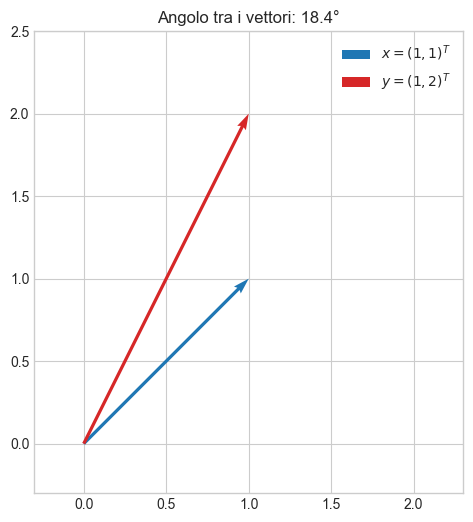

In [156]:
x = np.array([1.0, 1.0])
y = np.array([1.0, 2.0])

cos_omega = (x @ y) / (np.linalg.norm(x) * np.linalg.norm(y))
omega = np.arccos(np.clip(cos_omega, -1.0, 1.0))

print("cos(omega) =", cos_omega)
print("omega in radianti =", omega)
print("omega in gradi =", np.degrees(omega))

fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(0, 0, *x, angles="xy", scale_units="xy", scale=1,
          color="tab:blue", label=r"$x=(1,1)^T$")
ax.quiver(0, 0, *y, angles="xy", scale_units="xy", scale=1,
          color="tab:red", label=r"$y=(1,2)^T$")
ax.set_xlim(-0.3, 2.3)
ax.set_ylim(-0.3, 2.5)
ax.set_aspect("equal")
ax.set_title(f"Angolo tra i vettori: {np.degrees(omega):.1f}°")
ax.legend()
plt.show()

## Esempio 5 — Come verificare se due vettori sono ortogonali

Due vettori sono ortogonali se il loro prodotto scalare è nullo.

Consideriamo

$$
\boldsymbol{x}=\begin{bmatrix}2\\1\end{bmatrix},
\qquad
\boldsymbol{y}=\begin{bmatrix}-1\\2\end{bmatrix}.
$$

Calcoliamo:

$$
\boldsymbol{x}^T\boldsymbol{y}
=2\cdot(-1)+1\cdot2
=-2+2=0.
$$

Pertanto $\boldsymbol{x}$ e $\boldsymbol{y}$ sono ortogonali.

Se invece prendiamo

$$
\boldsymbol{z}=\begin{bmatrix}1\\1\end{bmatrix},
$$

otteniamo

$$
\boldsymbol{x}^T\boldsymbol{z}=2\cdot1+1\cdot1=3\neq0,
$$

quindi $\boldsymbol{x}$ e $\boldsymbol{z}$ non sono ortogonali.

## Esempio 6 — Una base ortonormale di $\mathbb{R}^2$

Consideriamo

$$
\boldsymbol{b}_1
=\frac{1}{\sqrt{2}}
\begin{bmatrix}1\\1\end{bmatrix},
\qquad
\boldsymbol{b}_2
=\frac{1}{\sqrt{2}}
\begin{bmatrix}-1\\1\end{bmatrix}.
$$

I due vettori hanno norma unitaria e prodotto scalare nullo:

$$
\|\boldsymbol{b}_1\|_2
=\|\boldsymbol{b}_2\|_2=1,
\qquad
\boldsymbol{b}_1^T\boldsymbol{b}_2=0.
$$

La matrice $B=[\boldsymbol{b}_1,\boldsymbol{b}_2]$ è pertanto ortogonale e soddisfa $B^TB=I$.

In [157]:
b1 = np.array([1.0, 1.0]) / np.sqrt(2)
b2 = np.array([-1.0, 1.0]) / np.sqrt(2)
B = np.column_stack([b1, b2])

print("||b1|| =", np.linalg.norm(b1))
print("||b2|| =", np.linalg.norm(b2))
print("b1.T @ b2 =", b1 @ b2)
print("B.T @ B =\n", np.round(B.T @ B, 12))

||b1|| = 0.9999999999999999
||b2|| = 0.9999999999999999
b1.T @ b2 = 2.2371143170757382e-17
B.T @ B =
 [[1. 0.]
 [0. 1.]]


## Esempio 6 — Proiezione ortogonale su una retta

Consideriamo la retta passante per l'origine generata da

$$
\boldsymbol{b}
=\begin{bmatrix}1\\2\\2\end{bmatrix}.
$$

La matrice di proiezione è

$$
P
=\frac{\boldsymbol{b}\boldsymbol{b}^T}
{\boldsymbol{b}^T\boldsymbol{b}}
=\frac{1}{9}
\begin{bmatrix}
1&2&2\\
2&4&4\\
2&4&4
\end{bmatrix}.
$$

Proiettiamo

$$
\boldsymbol{x}=\begin{bmatrix}1\\1\\1\end{bmatrix}.
$$

Otteniamo

$$
\pi_U(\boldsymbol{x})
=P\boldsymbol{x}
=\frac{1}{9}
\begin{bmatrix}5\\10\\10\end{bmatrix}.
$$

In [159]:
b = np.array([1.0, 2.0, 2.0])
x = np.array([1.0, 1.0, 1.0])

P = np.outer(b, b) / (b @ b)
proiezione = P @ x
errore = x - proiezione

print("P =\n", P)
print("proiezione =", proiezione)
print("errore =", errore)
print("b.T @ errore =", b @ errore)
print("P @ P = P?", np.allclose(P @ P, P))
print("P è simmetrica?", np.allclose(P.T, P))

P =
 [[0.11111111 0.22222222 0.22222222]
 [0.22222222 0.44444444 0.44444444]
 [0.22222222 0.44444444 0.44444444]]
proiezione = [0.55555556 1.11111111 1.11111111]
errore = [ 0.44444444 -0.11111111 -0.11111111]
b.T @ errore = -2.220446049250313e-16
P @ P = P? True
P è simmetrica? True


Le verifiche finali mostrano due proprietà fondamentali:

- $P^2=P$: proiettare due volte equivale a proiettare una volta;
- $\boldsymbol{b}^T(\boldsymbol{x}-P\boldsymbol{x})=0$: l'errore è ortogonale alla retta.

## Idee da ricordare

- La norma e il prodotto scalare scelti determinano la geometria dello spazio.
- Le matrici simmetriche definite positive definiscono prodotti scalari.
- L'ortogonalità non è limitata ai vettori: può riguardare anche funzioni.
- Una proiezione ortogonale fornisce la migliore approssimazione in un sottospazio.
- Gram–Schmidt costruisce una base ortonormale mediante proiezioni successive.
- Le rotazioni sono trasformazioni ortogonali e non deformano la geometria.